In this Notebook, we shall take a regular image and prepare it in such a way that it can be mapped to a Still Life.

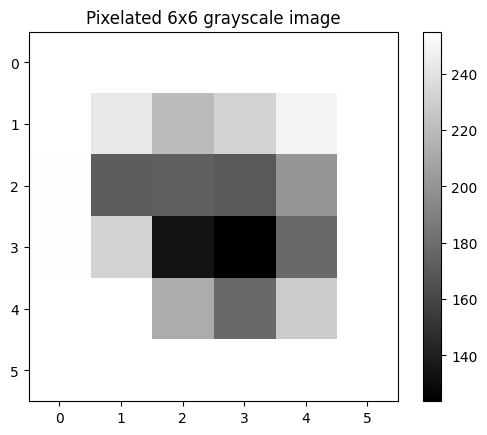

In [142]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def process_image(path, grid_size, expand=True):
    """
    1. Load image as grayscale
    2. Rotate 45 degrees
    3. Pixelate by averaging over blocks
    4. Return low-res numpy array
    """
    if grid_size % 2 != 0:
        raise ValueError("Grid size must be even for this implementation.")

    # 1. Load image in grayscale
    img = Image.open(path).convert('L')

    # 2. Rotate 45 degrees with expand so nothing is cut off
    img = img.rotate(45, expand=expand, fillcolor=255)

    # Convert to numpy
    arr = np.array(img)

    # 3. Compute block size (grid cell size)
    h, w = arr.shape
    cell_h = h // grid_size
    cell_w = w // grid_size

    # 4. Pixelate: mean of each cell
    lowres = np.zeros((grid_size, grid_size))

    for i in range(grid_size):
        for j in range(grid_size):
            block = arr[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            lowres[i, j] = np.mean(block)

    return lowres

# === Example usage ===
# NOTE: this entire thing only works for even grid sizes for now
# NOTE: this only works for square images
grid_size=6
lowres_array = process_image("images/orange.jpg", grid_size, expand=True)

# Display
plt.imshow(lowres_array, cmap='gray')
plt.title(f"Pixelated {grid_size}x{grid_size} grayscale image")
plt.colorbar()
plt.show()


Now we will split this image into two pixel subsets: the set of indices whose sum is even, and the set of indices whose sum is odd. The corresponding pixel values are mapped to Still Life tiles. These are added together (after a 45 degree rotation) and make up the complete Still Life.

In [143]:
diag_indices_even = [[(grid_size//2-1-i+j, i+j) for i in range(grid_size//2)] for j in range(grid_size//2+1)]
diag_indices_even = np.array(diag_indices_even)
print(diag_indices_even.shape)
diag_indices_even = diag_indices_even.reshape(-1,diag_indices_even.shape[-1])

(4, 3, 2)


In [144]:
diag_indices_odd = [[(grid_size//2-i+j, i+j) for i in range(grid_size//2+1)] for j in range(grid_size//2)]
diag_indices_odd = np.array(diag_indices_odd)
print(diag_indices_odd.shape)
diag_indices_odd = diag_indices_odd.reshape(-1,diag_indices_odd.shape[-1])

(3, 4, 2)


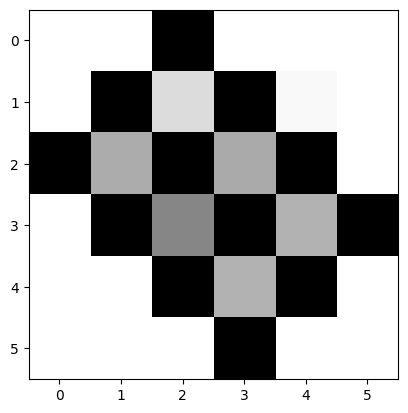

In [145]:
test = lowres_array.copy()

rows, cols = zip(*diag_indices_even)
test[rows, cols] = 0

rows, cols = zip(*diag_indices_odd)
# test[rows, cols] = 0

plt.imshow(test, cmap='gray')
# plt.axis('off')